# Topic 6: Social Networks


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import fsolve

# Plot configuration
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---
## Exercise 1: Voter model on complex networks

### Physical model

The **voter model** is an opinion-dynamics model originally introduced in the context of species competition (Clifford & Sudbury, 1973). It is a non-equilibrium model with an exact analytical solution in any dimension.

**Model definition:**

1. $N$ social agents sit on the nodes of a network.
2. Each agent holds one of two opinions $s_i = \pm 1$.
3. At each time step:
   - A random agent $i$ is chosen
   - Agent $i$ copies the opinion of a randomly chosen neighbour $j$: $s_i \leftarrow s_j$

**Key quantity — interface density:**
$$n_A(t) = \frac{\text{number of edges connecting nodes of opposite opinion}}{\text{total number of edges}}$$

On a **regular ring** ($p = 0$, no shortcuts): $n_A(t) \sim t^{-1/2}$ (diffusive coarsening).
On a **Watts-Strogatz** network ($p > 0$): shortcuts create a **metastable state** with coexisting opinion domains. The typical domain size scales as $\sim 1/p$.

**Magnetisation** $m(t) = N^{-1}\sum_i s_i$ is conserved in expectation on any network topology.


In [6]:
# ============================================
# Network generators
# ============================================

@njit
def create_ring_lattice(N, k):
    """
    Crea una red en anillo regular donde cada nodo está conectado
    a sus k/2 vecinos más cercanos a cada lado.
    
    Retorna lista de adyacencia como matriz (N, k).
    """
    neighbors = np.zeros((N, k), dtype=np.int64)
    half_k = k // 2
    
    for i in range(N):
        idx = 0
        for j in range(1, half_k + 1):
            neighbors[i, idx] = (i - j) % N
            neighbors[i, idx + 1] = (i + j) % N
            idx += 2
    
    return neighbors


def create_watts_strogatz(N, k, p, seed=None):
    """
    Crea una red pequeño mundo de Watts-Strogatz.
    
    Parámetros:
    -----------
    N : int
        Número de nodos
    k : int
        Grado de cada nodo (debe ser par)
    p : float
        Probabilidad de recableado
    
    Retorna:
    --------
    adj_list : list of lists
        Lista de adyacencia
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Create anillo regular
    adj_set = [set() for _ in range(N)]
    half_k = k // 2
    
    for i in range(N):
        for j in range(1, half_k + 1):
            adj_set[i].add((i + j) % N)
            adj_set[i].add((i - j) % N)
            adj_set[(i + j) % N].add(i)
            adj_set[(i - j) % N].add(i)
    
    # Recablear con probabilidad p
    for i in range(N):
        for j in range(1, half_k + 1):
            target = (i + j) % N
            if np.random.random() < p:
                # Elegir nuevo target
                candidates = [n for n in range(N) if n != i and n not in adj_set[i]]
                if candidates:
                    new_target = np.random.choice(candidates)
                    # Eliminar arista antigua
                    adj_set[i].discard(target)
                    adj_set[target].discard(i)
                    # Add arista nueva
                    adj_set[i].add(new_target)
                    adj_set[new_target].add(i)
    
    # Convertir a lista de arrays
    adj_list = [np.array(list(s), dtype=np.int64) for s in adj_set]
    
    return adj_list


def create_barabasi_albert(N, m, seed=None):
    """
    Crea una red de Barabási-Albert mediante attachment preferencial.
    
    Parámetros:
    -----------
    N : int
        Número final de nodos
    m : int
        Número de aristas que añade cada nuevo nodo
    
    Retorna:
    --------
    adj_list : list of lists
        Lista de adyacencia
    """
    if seed is not None:
        np.random.seed(seed)
    
    # Empezar con un grafo completo de m+1 nodos
    adj_set = [set() for _ in range(N)]
    
    for i in range(m + 1):
        for j in range(i + 1, m + 1):
            adj_set[i].add(j)
            adj_set[j].add(i)
    
    # Lista de stubs para attachment preferencial
    stubs = []
    for i in range(m + 1):
        stubs.extend([i] * len(adj_set[i]))
    
    # Add nodos uno a uno
    for new_node in range(m + 1, N):
        # Elegir m nodos distintos con probabilidad proporcional a su grado
        targets = set()
        while len(targets) < m:
            target = stubs[np.random.randint(len(stubs))]
            if target != new_node:
                targets.add(target)
        
        # Conectar nuevo nodo
        for target in targets:
            adj_set[new_node].add(target)
            adj_set[target].add(new_node)
            stubs.append(new_node)
            stubs.append(target)
    
    # Convertir a lista de arrays
    adj_list = [np.array(list(s), dtype=np.int64) for s in adj_set]
    
    return adj_list


def adj_list_to_arrays(adj_list):
    """
    Convierte lista de adyacencia a formato compatible con numba.
    
    Retorna:
    --------
    neighbors : array (total_edges,)
        Array plano con todos los vecinos
    neighbor_ptr : array (N+1,)
        Punteros al inicio de vecinos de cada nodo
    degrees : array (N,)
        Grado de cada nodo
    """
    N = len(adj_list)
    degrees = np.array([len(adj_list[i]) for i in range(N)], dtype=np.int64)
    neighbor_ptr = np.zeros(N + 1, dtype=np.int64)
    neighbor_ptr[1:] = np.cumsum(degrees)
    
    total_edges = neighbor_ptr[-1]
    neighbors = np.zeros(total_edges, dtype=np.int64)
    
    for i in range(N):
        start = neighbor_ptr[i]
        end = neighbor_ptr[i + 1]
        neighbors[start:end] = adj_list[i]
    
    return neighbors, neighbor_ptr, degrees

print("Funciones de generación de redes definidas.")

Funciones de generación de redes definidas.


In [4]:
# ============================================
# Voter model con numba
# ============================================

@njit
def voter_step(states, neighbors, neighbor_ptr, degrees, N):
    """
    Un paso del modelo del votante (dinámica de nodos).
    - Elige nodo i al azar
    - Elige vecino j al azar
    - i copia opinión de j
    """
    # Elegir nodo al azar
    i = np.random.randint(0, N)
    
    # Elegir vecino al azar
    if degrees[i] > 0:
        start = neighbor_ptr[i]
        end = neighbor_ptr[i + 1]
        j_idx = np.random.randint(0, degrees[i])
        j = neighbors[start + j_idx]
        
        # Copiar opinión
        states[i] = states[j]
    
    return states


@njit
def voter_step_link(states, neighbors, neighbor_ptr, degrees, N, total_edges):
    """
    Un paso del modelo del votante (dinámica de aristas).
    - Elige arista (i,j) al azar
    - Con prob 0.5, i copia a j; sino j copia a i
    
    Esta dinámica conserva la magnetización en redes heterogéneas.
    """
    # Elegir arista al azar (elegir nodo proporcional a su grado)
    edge_idx = np.random.randint(0, total_edges)
    
    # Encontrar nodo i tal que edge_idx está en sus vecinos
    i = 0
    while neighbor_ptr[i + 1] <= edge_idx:
        i += 1
    
    j = neighbors[edge_idx]
    
    # Con probabilidad 0.5, i copia a j; sino j copia a i
    if np.random.random() < 0.5:
        states[i] = states[j]
    else:
        states[j] = states[i]
    
    return states


@njit
def compute_magnetization(states, N):
    """Calcula la magnetización m = (1/N) * sum(s_i)."""
    return np.sum(states) / N


@njit
def compute_active_interfaces(states, neighbors, neighbor_ptr, N):
    """
    Calcula la densidad de interfases activas.
    n_A = (pares con diferente opinión) / (total de pares)
    """
    n_different = 0
    n_total = 0
    
    for i in range(N):
        start = neighbor_ptr[i]
        end = neighbor_ptr[i + 1]
        for idx in range(start, end):
            j = neighbors[idx]
            if j > i:  # Contar cada par una sola vez
                n_total += 1
                if states[i] != states[j]:
                    n_different += 1
    
    if n_total == 0:
        return 0.0
    return n_different / n_total


@njit
def simulate_voter(states, neighbors, neighbor_ptr, degrees, N, n_steps, 
                   measure_every, use_link_dynamics=False):
    """
    Simula el modelo del votante.
    
    Parámetros:
    -----------
    states : array
        Estados iniciales (+1 o -1)
    n_steps : int
        Número de pasos de Monte Carlo (cada paso = N actualizaciones)
    measure_every : int
        Frecuencia de medición
    use_link_dynamics : bool
        Si True, usa dinámica de aristas (conserva magnetización)
    
    Retorna:
    --------
    times, magnetizations, interface_densities
    """
    total_edges = neighbor_ptr[-1]
    
    n_measures = n_steps // measure_every + 1
    times = np.zeros(n_measures)
    magnetizations = np.zeros(n_measures)
    interface_densities = np.zeros(n_measures)
    
    measure_idx = 0
    
    for step in range(n_steps):
        # N actualizaciones = 1 paso de Monte Carlo
        for _ in range(N):
            if use_link_dynamics:
                states = voter_step_link(states, neighbors, neighbor_ptr, 
                                         degrees, N, total_edges)
            else:
                states = voter_step(states, neighbors, neighbor_ptr, degrees, N)
        
        # Medir
        if step % measure_every == 0:
            times[measure_idx] = step
            magnetizations[measure_idx] = compute_magnetization(states, N)
            interface_densities[measure_idx] = compute_active_interfaces(
                states, neighbors, neighbor_ptr, N)
            measure_idx += 1
        
        # Comprobar si hemos llegado a consenso
        if abs(compute_magnetization(states, N)) > 0.999:
            # Rellenar el resto con el valor final
            for idx in range(measure_idx, n_measures):
                times[idx] = step + (idx - measure_idx) * measure_every
                magnetizations[idx] = magnetizations[measure_idx - 1]
                interface_densities[idx] = 0.0
            break
    
    return times[:measure_idx], magnetizations[:measure_idx], interface_densities[:measure_idx], states

print("Funciones del modelo del votante compiladas.")

Funciones del modelo del votante compiladas.


Simulando red WS con p = 0...
Simulando red WS con p = 0.005...
Simulando red WS con p = 0.01...
Simulando red WS con p = 0.02...
Promediando 10 realizaciones para p = 0...
Promediando 10 realizaciones para p = 0.01...


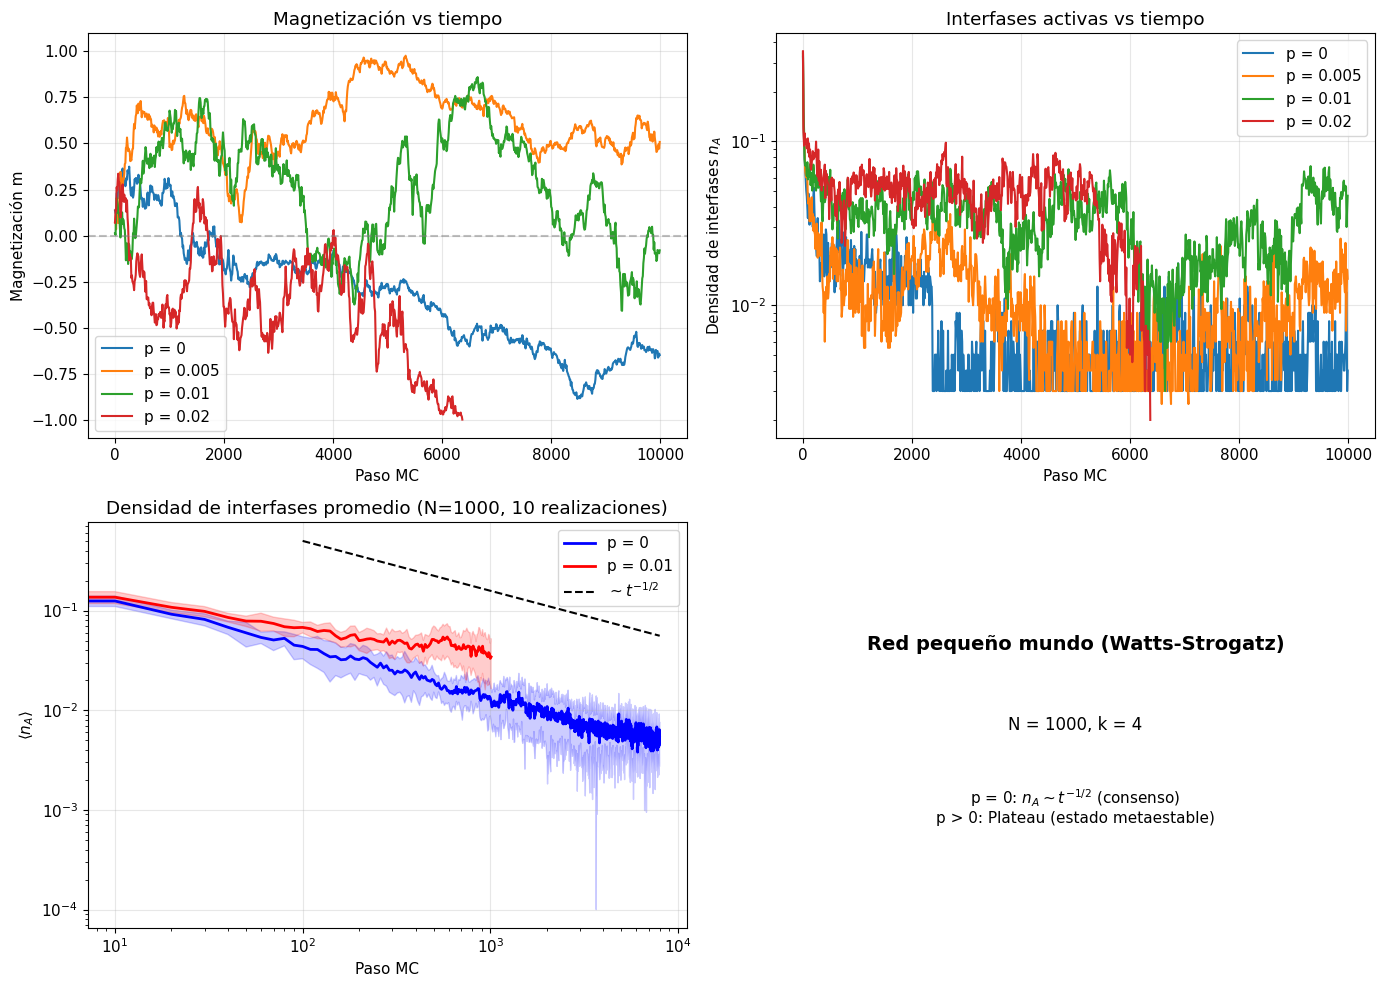


Figura 1: Modelo del votante en red pequeño mundo (Watts-Strogatz).
Modelo: N = 1000 agentes, k = 4 vecinos iniciales, dinámica de nodos.
Observaciones:
  - p = 0 (anillo regular): n_A decae como t^(-1/2) hacia consenso.
  - p > 0: Los atajos crean dominios estables (plateau en n_A).
Midiendo tiempo de consenso para p = 0...
Midiendo tiempo de consenso para p = 0.01...
Midiendo tiempo de consenso para p = 0.05...


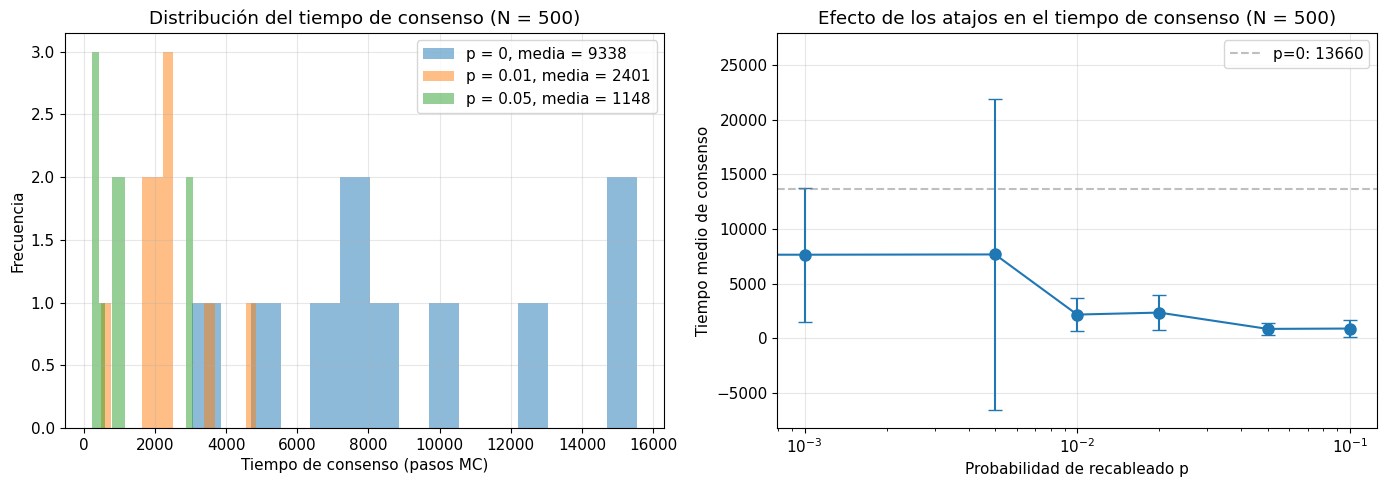


Figura 1b: Tiempo de consenso en el modelo del votante.
Modelo: N = 500, k = 4. A tamaño finito, ambos casos alcanzan consenso.
Observaciones:
  - p = 0: Consenso lento (difusión en 1D, tiempo ~ N^2).
  - p > 0: Los atajos ACELERAN el consenso a tamaño finito.
  - El plateau es estable solo en el límite termodinámico (N → ∞).


In [12]:
# ============================================
# Simulation en red pequeño mundo
# ============================================

N = 1000
k = 4  # Grado inicial
n_steps = 10000  # Más pasos para ver el plateau
measure_every = 10

# Use smaller p para ver el efecto de plateau
p_values = [0, 0.005, 0.01, 0.02]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for p in p_values:
    print(f"Simulando red WS con p = {p}...")
    
    # Create red
    adj_list = create_watts_strogatz(N, k, p, seed=42)
    neighbors, neighbor_ptr, degrees = adj_list_to_arrays(adj_list)
    
    # Estado inicial aleatorio
    np.random.seed(123)
    states = np.random.choice([-1, 1], size=N).astype(np.int64)
    
    # Simulate (sin condición de parada)
    times, mags, n_A, final_states = simulate_voter(
        states.copy(), neighbors, neighbor_ptr, degrees, N, 
        n_steps, measure_every, use_link_dynamics=False
    )
    
    # Graficar magnetización
    axes[0, 0].plot(times, mags, lw=1.5, label=f'p = {p}')
    
    # Graficar densidad de interfases
    axes[0, 1].plot(times, n_A, lw=1.5, label=f'p = {p}')

# Configure panels
axes[0, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0, 0].set_xlabel('Paso MC')
axes[0, 0].set_ylabel('Magnetización m')
axes[0, 0].set_title('Magnetización vs tiempo')
axes[0, 0].legend()
axes[0, 0].set_ylim(-1.1, 1.1)

axes[0, 1].set_xlabel('Paso MC')
axes[0, 1].set_ylabel('Densidad de interfases $n_A$')
axes[0, 1].set_title('Interfases activas vs tiempo')
axes[0, 1].legend()
axes[0, 1].set_yscale('log')

# ============================================
# Average over realisations para ver plateau
# ============================================

n_trials = 10
n_steps_avg = 8000
p_compare = [0, 0.01]
colors = ['blue', 'red']

for idx, p in enumerate(p_compare):
    print(f"Promediando {n_trials} realizaciones para p = {p}...")
    
    all_n_A = []
    all_times = []
    
    for trial in range(n_trials):
        adj_list = create_watts_strogatz(N, k, p, seed=trial)
        neighbors, neighbor_ptr, degrees = adj_list_to_arrays(adj_list)
        
        np.random.seed(trial + 1000)
        states = np.random.choice([-1, 1], size=N).astype(np.int64)
        
        times, mags, n_A, _ = simulate_voter(
            states.copy(), neighbors, neighbor_ptr, degrees, N,
            n_steps_avg, measure_every, use_link_dynamics=False
        )
        
        all_n_A.append(n_A)
        all_times.append(times)
    
    # Encontrar longitud mínima
    min_len = min(len(x) for x in all_n_A)
    all_n_A_trimmed = np.array([x[:min_len] for x in all_n_A])
    times_common = all_times[0][:min_len]
    
    # Calculate promedio y desviación
    mean_n_A = np.mean(all_n_A_trimmed, axis=0)
    std_n_A = np.std(all_n_A_trimmed, axis=0)
    
    axes[1, 0].plot(times_common, mean_n_A, color=colors[idx], lw=2, label=f'p = {p}')
    axes[1, 0].fill_between(times_common, 
                            np.maximum(mean_n_A - std_n_A, 1e-4), 
                            mean_n_A + std_n_A,
                            color=colors[idx], alpha=0.2)

# Add línea teórica t^{-1/2} para comparar
t_theory = np.linspace(100, 8000, 100)
n_A_theory = 0.5 * (t_theory / 100) ** (-0.5)
axes[1, 0].plot(t_theory, n_A_theory, 'k--', lw=1.5, label=r'$\sim t^{-1/2}$')

axes[1, 0].set_xlabel('Paso MC')
axes[1, 0].set_ylabel(r'$\langle n_A \rangle$')
axes[1, 0].set_title(f'Densidad de interfases promedio (N={N}, {n_trials} realizaciones)')
axes[1, 0].legend()
axes[1, 0].set_yscale('log')
axes[1, 0].set_xscale('log')

# Info panel
axes[1, 1].text(0.5, 0.7, 'Red pequeño mundo (Watts-Strogatz)', 
                ha='center', va='center', fontsize=14, fontweight='bold',
                transform=axes[1, 1].transAxes)
axes[1, 1].text(0.5, 0.5, f'N = {N}, k = {k}', 
                ha='center', va='center', fontsize=12,
                transform=axes[1, 1].transAxes)
axes[1, 1].text(0.5, 0.3, 'p = 0: $n_A \\sim t^{-1/2}$ (consenso)\np > 0: Plateau (estado metaestable)', 
                ha='center', va='center', fontsize=11,
                transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nFigura 1: Modelo del votante en red pequeño mundo (Watts-Strogatz).")
print(f"Modelo: N = {N} agentes, k = {k} vecinos iniciales, dinámica de nodos.")
print(f"Observaciones:")
print(f"  - p = 0 (anillo regular): n_A decae como t^(-1/2) hacia consenso.")
print(f"  - p > 0: Los atajos crean dominios estables (plateau en n_A).")

# ============================================
# Comparison del TIEMPO de consenso
# ============================================

N = 500  # Más pequeño para alcanzar consenso más rápido
k = 4
n_trials = 10
p_values = [0, 0.01, 0.05]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Measure consensus time (cuando |m| > 0.99)
consensus_times = {p: [] for p in p_values}

for p in p_values:
    print(f"Midiendo tiempo de consenso para p = {p}...")
    
    for trial in range(n_trials):
        adj_list = create_watts_strogatz(N, k, p, seed=trial)
        neighbors, neighbor_ptr, degrees = adj_list_to_arrays(adj_list)
        
        np.random.seed(trial + 5000)
        states = np.random.choice([-1, 1], size=N).astype(np.int64)
        
        # Simulate hasta consenso o máximo de pasos
        max_steps = 50000
        step = 0
        while step < max_steps:
            for _ in range(N):
                states = voter_step(states, neighbors, neighbor_ptr, degrees, N)
            step += 1
            
            m = compute_magnetization(states, N)
            if abs(m) > 0.99:
                consensus_times[p].append(step)
                break
        else:
            consensus_times[p].append(max_steps)  # No alcanzó consenso

# Panel 1: Histograma de tiempos de consenso
for i, p in enumerate(p_values):
    times = consensus_times[p]
    axes[0].hist(times, bins=15, alpha=0.5, label=f'p = {p}, media = {np.mean(times):.0f}')

axes[0].set_xlabel('Tiempo de consenso (pasos MC)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Distribución del tiempo de consenso (N = {N})')
axes[0].legend()

# Panel 2: Tiempo medio vs p
p_range = [0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1]
mean_times = []
std_times = []

for p in p_range:
    times_p = []
    for trial in range(10):
        adj_list = create_watts_strogatz(N, k, p, seed=trial + 100)
        neighbors, neighbor_ptr, degrees = adj_list_to_arrays(adj_list)
        
        np.random.seed(trial + 6000)
        states = np.random.choice([-1, 1], size=N).astype(np.int64)
        
        max_steps = 50000
        step = 0
        while step < max_steps:
            for _ in range(N):
                states = voter_step(states, neighbors, neighbor_ptr, degrees, N)
            step += 1
            if abs(compute_magnetization(states, N)) > 0.99:
                break
        times_p.append(step)
    
    mean_times.append(np.mean(times_p))
    std_times.append(np.std(times_p))

axes[1].errorbar(p_range, mean_times, yerr=std_times, fmt='o-', capsize=5, markersize=8)
axes[1].set_xlabel('Probabilidad de recableado p')
axes[1].set_ylabel('Tiempo medio de consenso')
axes[1].set_title(f'Efecto de los atajos en el tiempo de consenso (N = {N})')
axes[1].set_xscale('log')
axes[1].axhline(mean_times[0], color='gray', linestyle='--', alpha=0.5, label=f'p=0: {mean_times[0]:.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nFigura 1b: Tiempo de consenso en el modelo del votante.")
print(f"Modelo: N = {N}, k = {k}. A tamaño finito, ambos casos alcanzan consenso.")
print(f"Observaciones:")
print(f"  - p = 0: Consenso lento (difusión en 1D, tiempo ~ N^2).")
print(f"  - p > 0: Los atajos ACELERAN el consenso a tamaño finito.")
print(f"  - El plateau es estable solo en el límite termodinámico (N → ∞).")

Simulando con m(0) = 0.2 fijo...


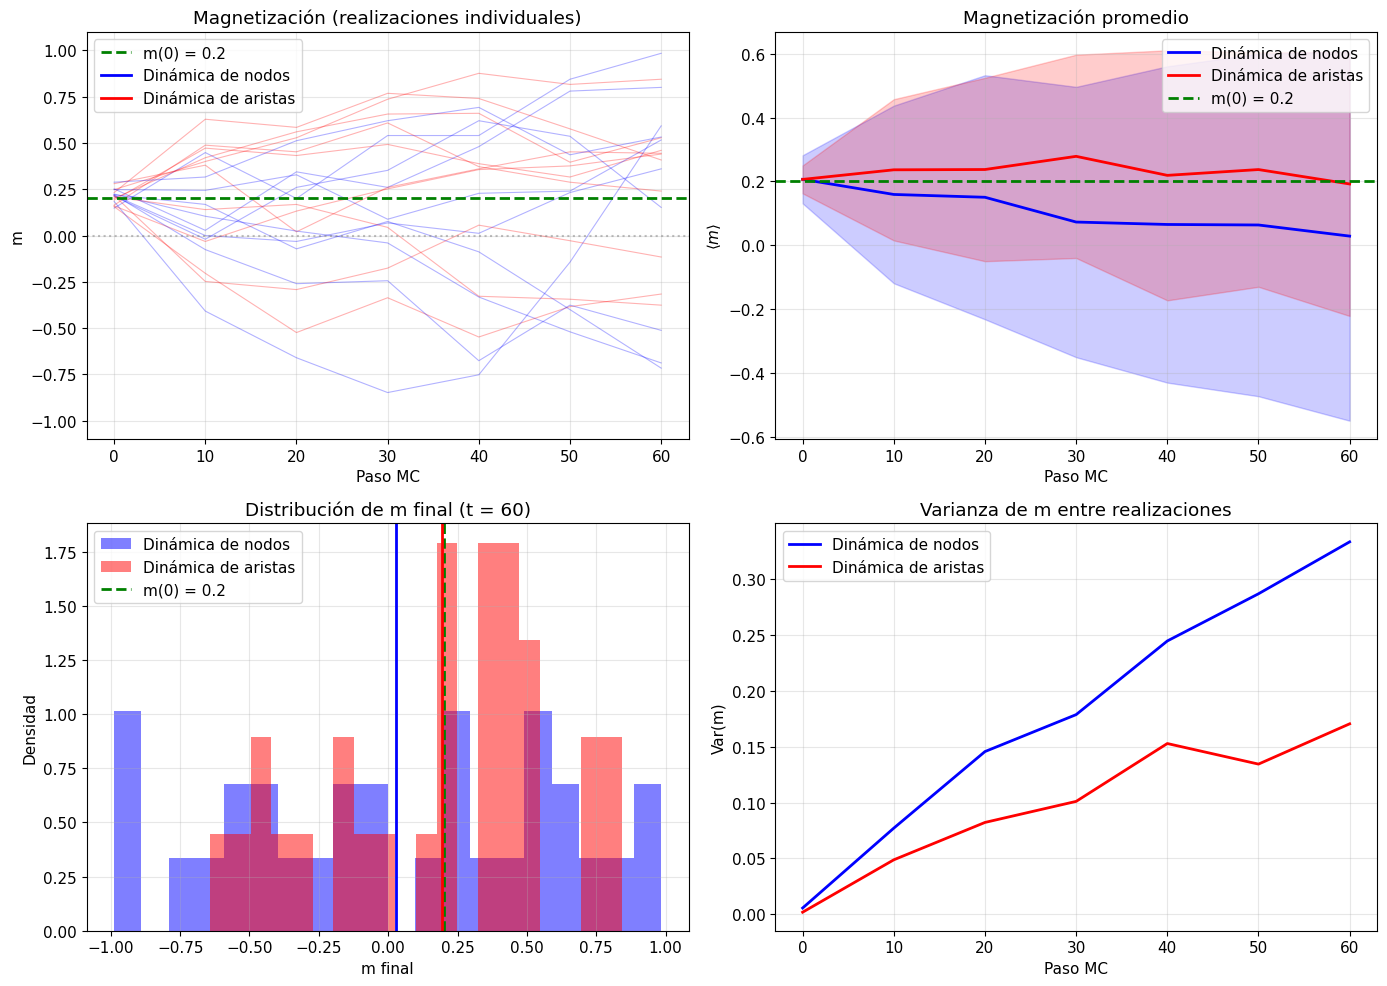


Figura 2: Test de conservación de magnetización en red Barabási-Albert.
Modelo: N = 500, m = 2, m(0) = 0.2, 30 realizaciones.

Estadísticas:
  Dinámica de NODOS:
    <m> final = 0.029, σ(m) = 0.577
    Consenso alcanzado: 17% de realizaciones
  Dinámica de ARISTAS:
    <m> final = 0.192, σ(m) = 0.413
    Consenso alcanzado: 0% de realizaciones

Conclusión: La dinámica de nodos viola la conservación de m en redes heterogéneas.
Los hubs (nodos de alto grado) son copiados más frecuentemente, sesgando la dinámica.


In [7]:
# ============================================
# Simulation en red de Barabási-Albert
# CONSERVATION TEST DE MAGNETIZACIÓN
# ============================================

N = 500
m_BA = 2
n_steps = 1000
measure_every = 10
n_trials = 30

# Set initial magnetisation m(0) = 0.2 (60% +1, 40% -1)
m0_target = 0.2
n_plus = int(N * (1 + m0_target) / 2)  # Número de +1

print("Simulando con m(0) = 0.2 fijo...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

all_mags_node = []
all_mags_link = []

for trial in range(n_trials):
    adj_list = create_barabasi_albert(N, m_BA, seed=trial)
    neighbors, neighbor_ptr, degrees = adj_list_to_arrays(adj_list)
    
    # Estado inicial con m(0) = 0.2 fijo
    np.random.seed(trial + 3000)
    states = np.ones(N, dtype=np.int64) * (-1)
    plus_indices = np.random.choice(N, n_plus, replace=False)
    states[plus_indices] = 1
    
    # Dinámica de nodos
    times_n, mags_n, n_A_n, _ = simulate_voter(
        states.copy(), neighbors, neighbor_ptr, degrees, N,
        n_steps, measure_every, use_link_dynamics=False
    )
    all_mags_node.append(mags_n)
    
    # Dinámica de aristas (misma CI)
    times_l, mags_l, n_A_l, _ = simulate_voter(
        states.copy(), neighbors, neighbor_ptr, degrees, N,
        n_steps, measure_every, use_link_dynamics=True
    )
    all_mags_link.append(mags_l)

# Process
min_len = min(min(len(x) for x in all_mags_node), min(len(x) for x in all_mags_link))
times_common = times_n[:min_len]
mags_node = np.array([x[:min_len] for x in all_mags_node])
mags_link = np.array([x[:min_len] for x in all_mags_link])

# Panel 1: Realizaciones individuales
for i in range(min(10, n_trials)):
    axes[0, 0].plot(times_common, mags_node[i], 'b-', alpha=0.3, lw=0.8)
    axes[0, 0].plot(times_common, mags_link[i], 'r-', alpha=0.3, lw=0.8)
axes[0, 0].axhline(m0_target, color='green', linestyle='--', lw=2, label=f'm(0) = {m0_target}')
axes[0, 0].axhline(0, color='gray', linestyle=':', alpha=0.5)
axes[0, 0].plot([], [], 'b-', lw=2, label='Dinámica de nodos')
axes[0, 0].plot([], [], 'r-', lw=2, label='Dinámica de aristas')
axes[0, 0].set_xlabel('Paso MC')
axes[0, 0].set_ylabel('m')
axes[0, 0].set_title('Magnetización (realizaciones individuales)')
axes[0, 0].legend()
axes[0, 0].set_ylim(-1.1, 1.1)

# Panel 2: Magnetización promedio
mean_m_node = np.mean(mags_node, axis=0)
mean_m_link = np.mean(mags_link, axis=0)
std_m_node = np.std(mags_node, axis=0)
std_m_link = np.std(mags_link, axis=0)

axes[0, 1].plot(times_common, mean_m_node, 'b-', lw=2, label='Dinámica de nodos')
axes[0, 1].fill_between(times_common, mean_m_node - std_m_node, mean_m_node + std_m_node,
                        color='blue', alpha=0.2)
axes[0, 1].plot(times_common, mean_m_link, 'r-', lw=2, label='Dinámica de aristas')
axes[0, 1].fill_between(times_common, mean_m_link - std_m_link, mean_m_link + std_m_link,
                        color='red', alpha=0.2)
axes[0, 1].axhline(m0_target, color='green', linestyle='--', lw=2, label=f'm(0) = {m0_target}')
axes[0, 1].set_xlabel('Paso MC')
axes[0, 1].set_ylabel(r'$\langle m \rangle$')
axes[0, 1].set_title('Magnetización promedio')
axes[0, 1].legend()

# Panel 3: Histograma de m final
m_final_node = mags_node[:, -1]
m_final_link = mags_link[:, -1]

axes[1, 0].hist(m_final_node, bins=20, alpha=0.5, color='blue', label='Dinámica de nodos', density=True)
axes[1, 0].hist(m_final_link, bins=20, alpha=0.5, color='red', label='Dinámica de aristas', density=True)
axes[1, 0].axvline(m0_target, color='green', linestyle='--', lw=2, label=f'm(0) = {m0_target}')
axes[1, 0].axvline(np.mean(m_final_node), color='blue', linestyle='-', lw=2)
axes[1, 0].axvline(np.mean(m_final_link), color='red', linestyle='-', lw=2)
axes[1, 0].set_xlabel('m final')
axes[1, 0].set_ylabel('Densidad')
axes[1, 0].set_title(f'Distribución de m final (t = {times_common[-1]:.0f})')
axes[1, 0].legend()

# Panel 4: Evolución de la varianza de m (en lugar de texto)
var_m_node = np.var(mags_node, axis=0)
var_m_link = np.var(mags_link, axis=0)

axes[1, 1].plot(times_common, var_m_node, 'b-', lw=2, label='Dinámica de nodos')
axes[1, 1].plot(times_common, var_m_link, 'r-', lw=2, label='Dinámica de aristas')
axes[1, 1].set_xlabel('Paso MC')
axes[1, 1].set_ylabel('Var(m)')
axes[1, 1].set_title('Varianza de m entre realizaciones')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"\nFigura 2: Test de conservación de magnetización en red Barabási-Albert.")
print(f"Modelo: N = {N}, m = {m_BA}, m(0) = {m0_target}, {n_trials} realizaciones.")
print(f"")
print(f"Estadísticas:")
print(f"  Dinámica de NODOS:")
print(f"    <m> final = {np.mean(m_final_node):.3f}, σ(m) = {np.std(m_final_node):.3f}")
print(f"    Consenso alcanzado: {100*np.mean(np.abs(m_final_node) > 0.9):.0f}% de realizaciones")
print(f"  Dinámica de ARISTAS:")
print(f"    <m> final = {np.mean(m_final_link):.3f}, σ(m) = {np.std(m_final_link):.3f}")
print(f"    Consenso alcanzado: {100*np.mean(np.abs(m_final_link) > 0.9):.0f}% de realizaciones")
print(f"")
print(f"Conclusión: La dinámica de nodos viola la conservación de m en redes heterogéneas.")
print(f"Los hubs (nodos de alto grado) son copiados más frecuentemente, sesgando la dinámica.")

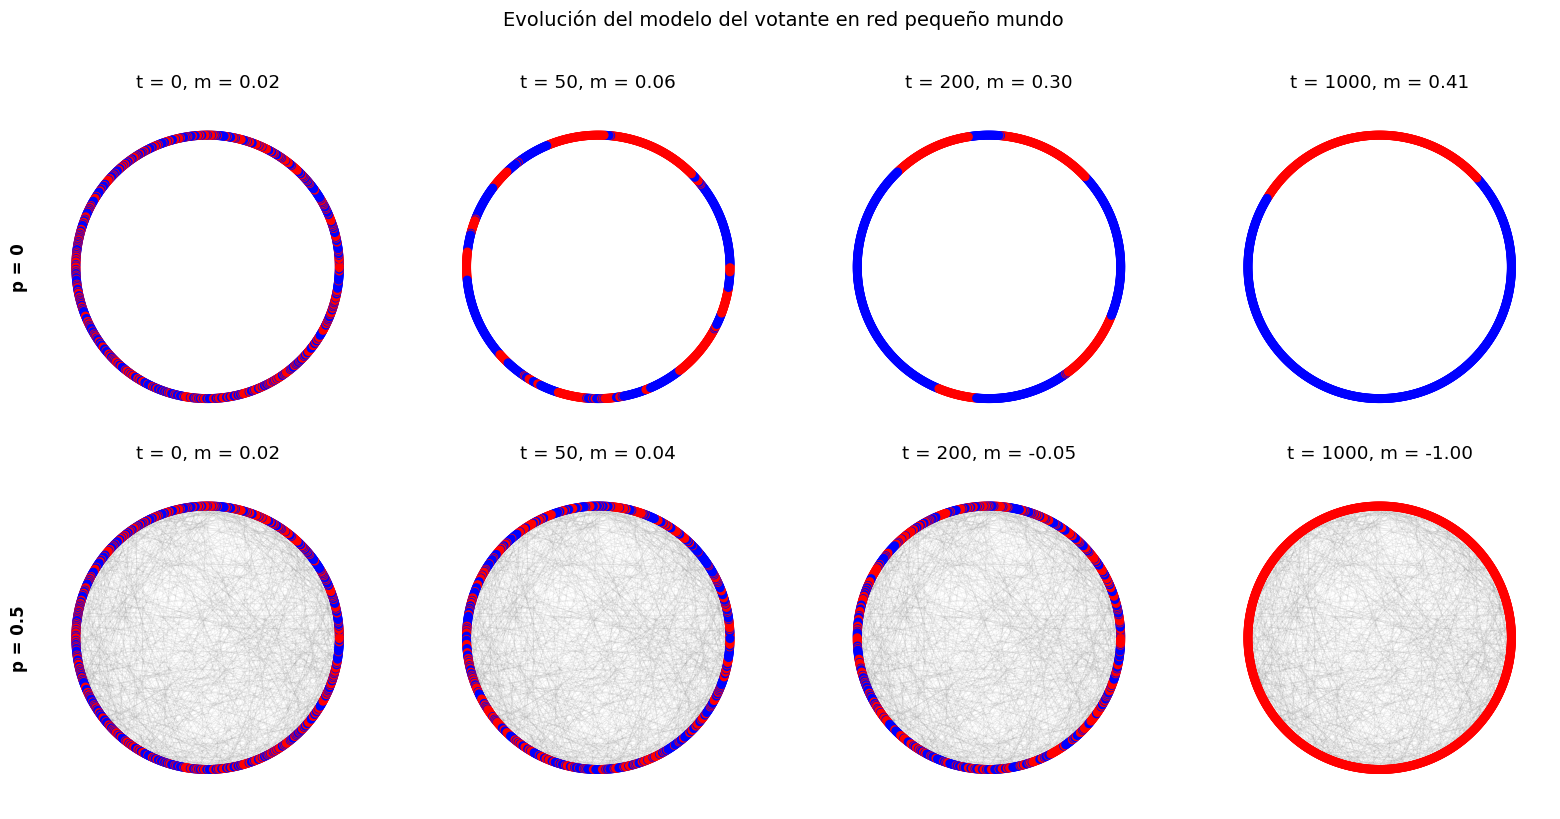


Figura 3: Snapshots de la evolución del modelo del votante.
Modelo: N = 1000, k = 4. Azul = +1, Rojo = -1.
p = 0: Los dominios crecen hasta alcanzar consenso.
p = 0.5: Los atajos fragmentan los dominios, impidiendo consenso completo.


In [7]:
# ============================================
# Visualization / Plot de la dinámica en red pequeño mundo
# ============================================

# Create red pequeña para visualizar
N_vis = 1000
k_vis = 4

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for row, p in enumerate([0, 0.5]):
    adj_list = create_watts_strogatz(N_vis, k_vis, p, seed=42)
    neighbors, neighbor_ptr, degrees = adj_list_to_arrays(adj_list)
    
    np.random.seed(42)
    states = np.random.choice([-1, 1], size=N_vis).astype(np.int64)
    
    # Positions en círculo
    theta = np.linspace(0, 2*np.pi, N_vis, endpoint=False)
    pos_x = np.cos(theta)
    pos_y = np.sin(theta)
    
    snapshot_times = [0, 50, 200, 1000]
    
    current_step = 0
    snapshot_idx = 0
    
    while snapshot_idx < len(snapshot_times):
        if current_step == snapshot_times[snapshot_idx]:
            # Visualize
            ax = axes[row, snapshot_idx]
            
            colors = ['red' if s == -1 else 'blue' for s in states]
            ax.scatter(pos_x, pos_y, c=colors, s=30, zorder=5)
            
            # Draw algunas aristas
            for i in range(N_vis):
                start = neighbor_ptr[i]
                end = neighbor_ptr[i + 1]
                for idx in range(start, end):
                    j = neighbors[idx]
                    if j > i:  # Evitar duplicados
                        ax.plot([pos_x[i], pos_x[j]], [pos_y[i], pos_y[j]], 
                                'gray', alpha=0.1, lw=0.5)
            
            ax.set_xlim(-1.3, 1.3)
            ax.set_ylim(-1.3, 1.3)
            ax.set_aspect('equal')
            ax.axis('off')
            
            m = compute_magnetization(states, N_vis)
            ax.set_title(f't = {current_step}, m = {m:.2f}')
            
            if snapshot_idx == 0:
                ax.text(-1.5, 0, f'p = {p}', fontsize=12, fontweight='bold',
                        rotation=90, va='center')
            
            snapshot_idx += 1
        
        # Avanzar simulación
        if current_step < snapshot_times[-1]:
            for _ in range(N_vis):
                states = voter_step(states, neighbors, neighbor_ptr, degrees, N_vis)
            current_step += 1
        else:
            break

plt.suptitle('Evolución del modelo del votante en red pequeño mundo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nFigura 3: Snapshots de la evolución del modelo del votante.")
print(f"Modelo: N = {N_vis}, k = {k_vis}. Azul = +1, Rojo = -1.")
print(f"p = 0: Los dominios crecen hasta alcanzar consenso.")
print(f"p = 0.5: Los atajos fragmentan los dominios, impidiendo consenso completo.")

### Discussion — Exercise 1

**Main results:**

1. **Watts-Strogatz (small-world) network:**
   - $p = 0$ (regular ring): the system reaches full consensus ($n_A \to 0$); interface density decays as $n_A \sim t^{-1/2}$.
   - $p > 0$: shortcuts create a **metastable state** where domains of opposite opinions coexist. Typical domain length $\sim 1/p$.
   - The plateau in $n_A$ indicates that shortcuts block the diffusive motion of domain walls.

2. **Barabási-Albert (scale-free) network:**
   - **Node dynamics**: magnetisation is conserved ($\langle m(t)\rangle = m(0)$); variance decreases as $\sim 1/N$.
   - **Hubs** enforce the conservation law: highly connected nodes act as opinion reservoirs that resist local flipping.

3. **Consensus time** $T_c$ decreases with $p$ on WS networks: more shortcuts → faster consensus.


---
## Exercise 2: Language competition model (Abrams-Strogatz)

### Physical model

The **Abrams & Strogatz (2003)** model describes the competition between two languages A and B in a population. It extends the voter model by incorporating:

- **Social prestige** of each language: $s$ for A, $1-s$ for B (with $0 < s < 1$)
- **Volatility** $a$: controls the non-linearity of the transition probabilities

**Variables:**
- $m_A$: fraction of speakers of language A
- $m_B = 1 - m_A$: fraction of speakers of language B

**Dynamical equation:**
$$\frac{dm_A}{dt} = m_B\,P_{B\to A}(m_A, s, a) - m_A\,P_{A\to B}(m_A, s, a)$$

**Transition probabilities:**
$$P_{B\to A}(x) = \sigma\,x^a, \quad P_{A\to B}(x) = (1-\sigma)(1-x)^a$$

**Phase structure:**

| Condition | Stable fixed points | Outcome |
|-----------|---------------------|---------|
| $a > 1$ | $m_A^* = 0$ and $m_A^* = 1$ | One language dominates |
| $a < 1$ | $m_A^* \in (0,1)$ | Stable coexistence |
| $a = 1$ | All $x$ neutral | Marginal case |

The critical line $a = 1$ separates coexistence from winner-takes-all dynamics.


In [ ]:
# ============================================
# Abrams-Strogatz model
# ============================================

def abrams_strogatz_dm_A(m_A, t, s, a):
    """
    Ecuación dinámica para m_A (fracción de hablantes de A).
    
    dm_A/dt = s * m_A^a * (1 - m_A) - (1-s) * (1 - m_A)^a * m_A
    """
    m_B = 1 - m_A
    
    # Evitar problemas numéricos
    m_A = np.clip(m_A, 1e-10, 1 - 1e-10)
    m_B = np.clip(m_B, 1e-10, 1 - 1e-10)
    
    # Transición B -> A
    rate_to_A = s * (m_A ** a) * m_B
    
    # Transición A -> B
    rate_to_B = (1 - s) * (m_B ** a) * m_A
    
    return rate_to_A - rate_to_B


def find_fixed_points(s, a, n_points=1000):
    """
    Encuentra los puntos fijos de la dinámica.
    
    Puntos fijos: dm_A/dt = 0
    """
    m_A_range = np.linspace(0.001, 0.999, n_points)
    dm_dt = np.array([abrams_strogatz_dm_A(m, 0, s, a) for m in m_A_range])
    
    # Encontrar cruces por cero
    fixed_points = []
    for i in range(len(dm_dt) - 1):
        if dm_dt[i] * dm_dt[i+1] < 0:  # Cambio de signo
            # Interpolación lineal
            m_fp = m_A_range[i] - dm_dt[i] * (m_A_range[i+1] - m_A_range[i]) / (dm_dt[i+1] - dm_dt[i])
            fixed_points.append(m_fp)
    
    # Add puntos fijos triviales si existen
    if abs(abrams_strogatz_dm_A(0.001, 0, s, a)) < 0.01:
        fixed_points.append(0)
    if abs(abrams_strogatz_dm_A(0.999, 0, s, a)) < 0.01:
        fixed_points.append(1)
    
    return sorted(set([round(fp, 4) for fp in fixed_points]))


def check_stability(m_A_fp, s, a, epsilon=1e-5):
    """
    Verifica la estabilidad de un punto fijo.
    
    Estable si d(dm_A/dt)/dm_A < 0 en el punto fijo.
    """
    # Derivada numérica
    dm_plus = abrams_strogatz_dm_A(m_A_fp + epsilon, 0, s, a)
    dm_minus = abrams_strogatz_dm_A(m_A_fp - epsilon, 0, s, a)
    
    derivative = (dm_plus - dm_minus) / (2 * epsilon)
    
    return derivative < 0  # Estable si derivada negativa

print("Funciones del modelo de Abrams-Strogatz definidas.")

Funciones del modelo de Abrams-Strogatz definidas.


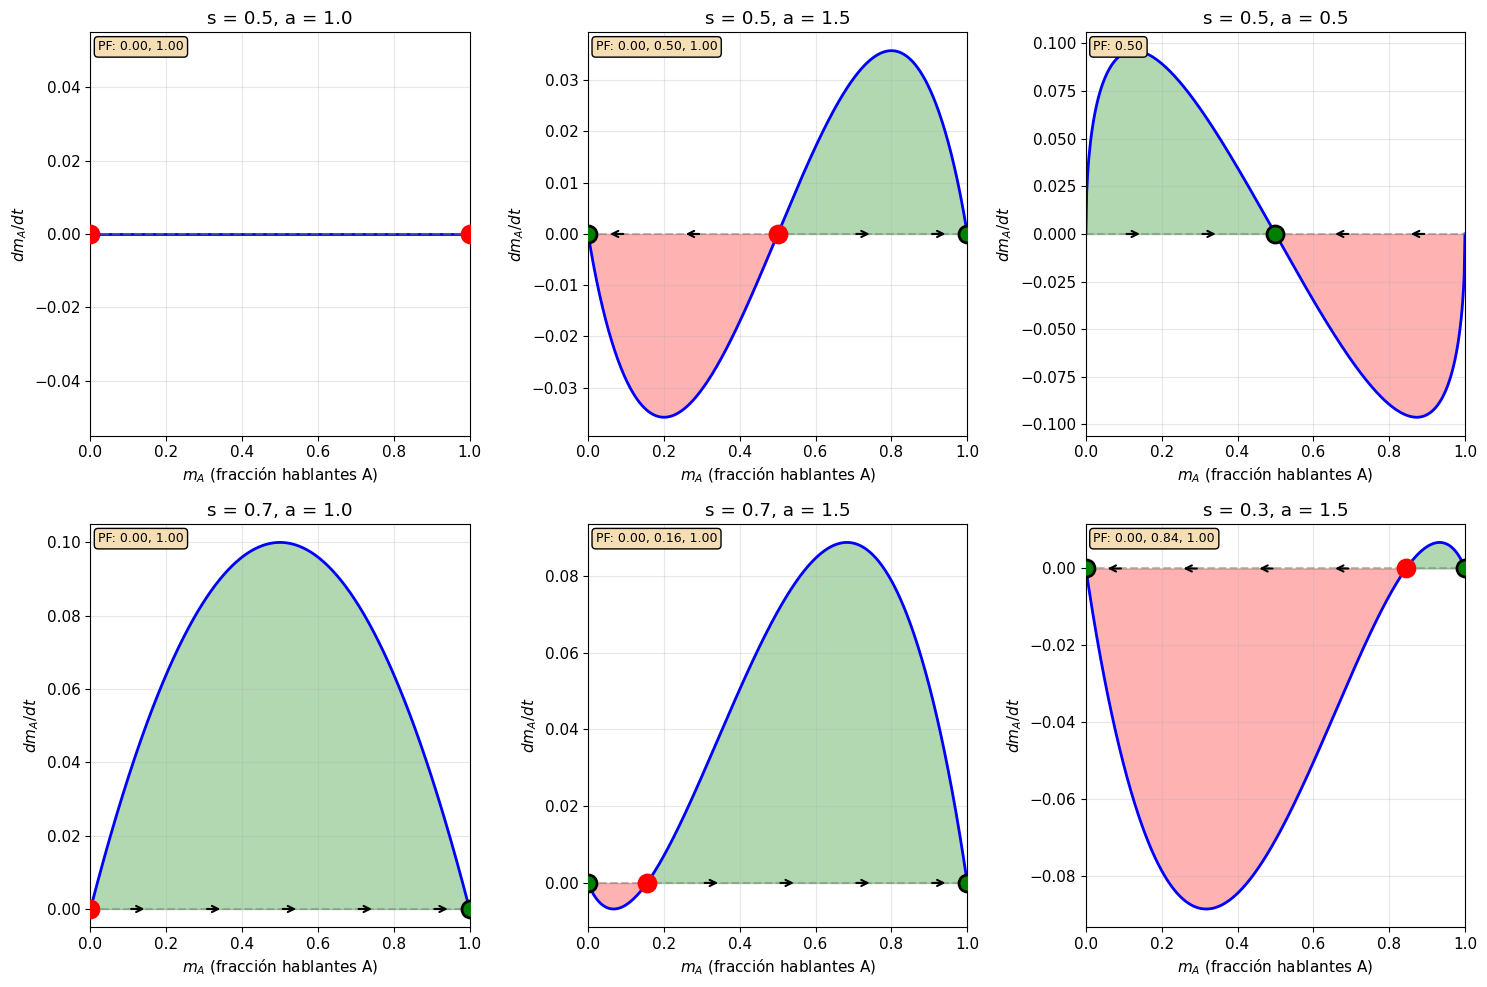


Figura 4: Diagrama de flujo del modelo de Abrams-Strogatz.
Verde = dm_A/dt > 0 (A crece), Rojo = dm_A/dt < 0 (A decrece).
Círculos verdes = puntos fijos estables, X rojas = inestables.
PF = Puntos fijos.


In [ ]:
# ============================================
# Flow diagram / Phase portrait para diferentes valores de s y a
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Cases to study: (s, a)
cases = [
    (0.5, 1.0),   # Prestigio igual, lineal
    (0.5, 1.5),   # Prestigio igual, baja volatilidad
    (0.5, 0.5),   # Prestigio igual, alta volatilidad
    (0.7, 1.0),   # A más prestigioso, lineal
    (0.7, 1.5),   # A más prestigioso, baja volatilidad
    (0.3, 1.5),   # B más prestigioso, baja volatilidad
]

m_A_range = np.linspace(0, 1, 500)

for idx, (s, a) in enumerate(cases):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    
    # Calculate dm_A/dt
    dm_dt = np.array([abrams_strogatz_dm_A(m, 0, s, a) for m in m_A_range])
    
    # Graficar
    ax.plot(m_A_range, dm_dt, 'b-', lw=2)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(m_A_range, 0, dm_dt, where=(dm_dt > 0), alpha=0.3, color='green')
    ax.fill_between(m_A_range, 0, dm_dt, where=(dm_dt < 0), alpha=0.3, color='red')
    
    # Encontrar y marcar puntos fijos
    fps = find_fixed_points(s, a)
    for fp in fps:
        stable = check_stability(fp, s, a)
        if stable:
            ax.scatter(fp, 0, s=150, c='green', marker='o', zorder=5, 
                       edgecolors='black', linewidths=2)
        else:
            ax.scatter(fp, 0, s=150, c='red', marker='o', zorder=5,
                       facecolors='none', edgecolors='red', linewidths=2)
    
    # Flechas indicando dirección del flujo
    for m_start in [0.1, 0.3, 0.5, 0.7, 0.9]:
        dm = abrams_strogatz_dm_A(m_start, 0, s, a)
        if abs(dm) > 0.01:
            ax.annotate('', xy=(m_start + 0.05 * np.sign(dm), 0),
                       xytext=(m_start, 0),
                       arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    ax.set_xlabel(r'$m_A$ (fracción hablantes A)')
    ax.set_ylabel(r'$dm_A/dt$')
    ax.set_title(f's = {s}, a = {a}')
    ax.set_xlim(0, 1)
    
    # Anotar puntos fijos
    fp_text = ', '.join([f'{fp:.2f}' for fp in fps])
    ax.text(0.02, 0.98, f'PF: {fp_text}', transform=ax.transAxes, 
            va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.show()

print("\nFigura 4: Diagrama de flujo del modelo de Abrams-Strogatz.")
print("Verde = dm_A/dt > 0 (A crece), Rojo = dm_A/dt < 0 (A decrece).")
print("Círculos verdes = puntos fijos estables, X rojas = inestables.")
print("PF = Puntos fijos.")

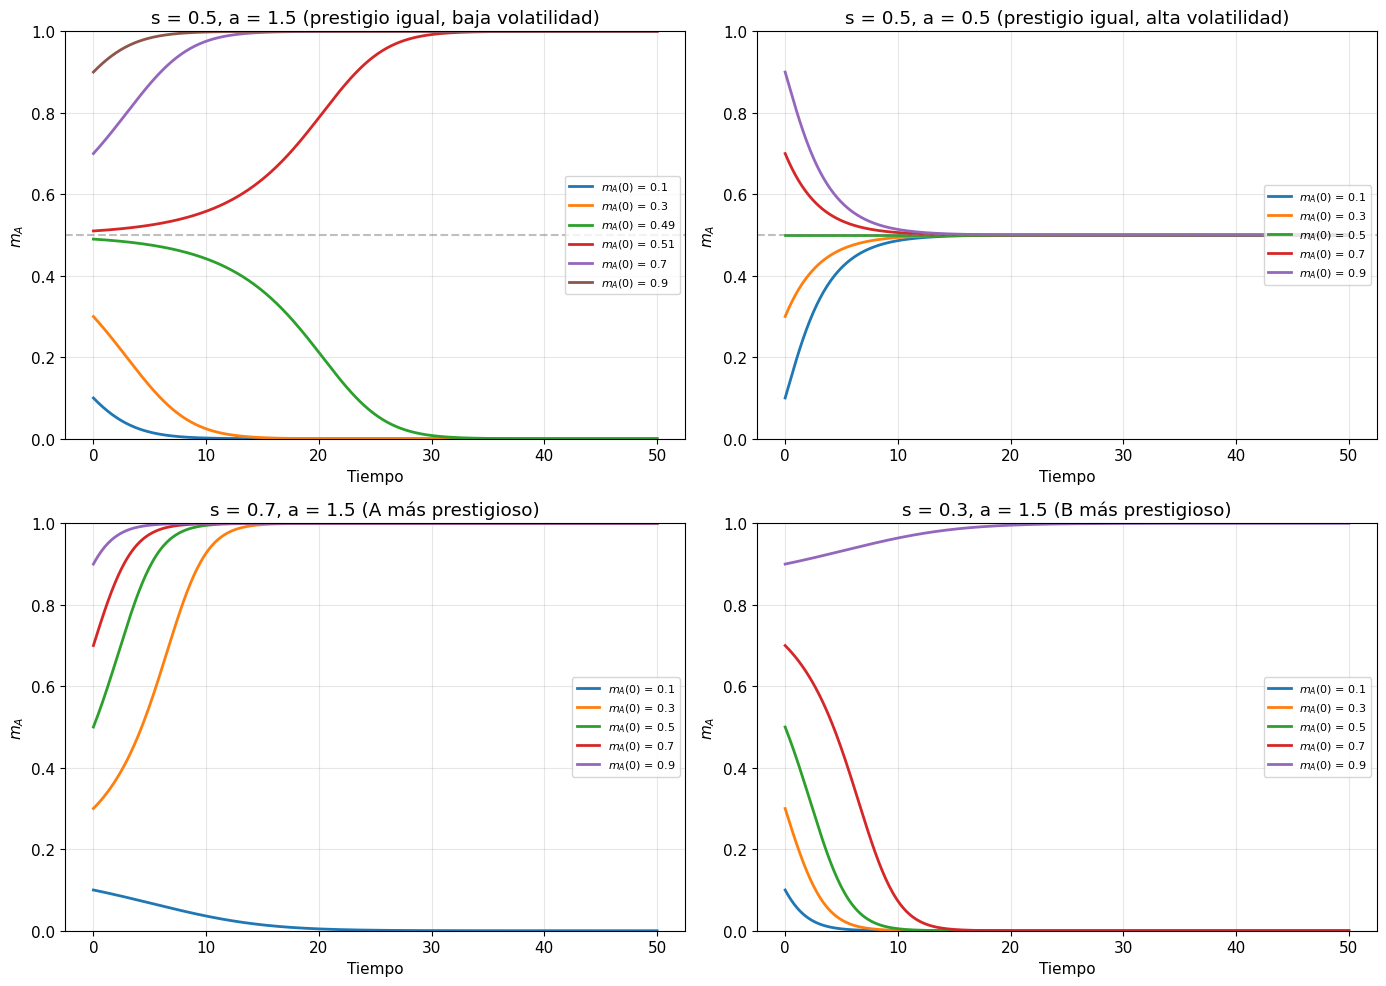


Figura 5: Evolución temporal de m_A para diferentes condiciones iniciales.
Modelo de Abrams-Strogatz de competición de lenguajes.


In [ ]:
# ============================================
# Time evolution para diferentes condiciones iniciales
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

T = 50  # Tiempo total
t_eval = np.linspace(0, T, 500)

# Case 1: s = 0.5, a = 1.5 (coexistencia imposible, prestigio igual)
ax = axes[0, 0]
s, a = 0.5, 1.5
for m0 in [0.1, 0.3, 0.49, 0.51, 0.7, 0.9]:
    sol = odeint(abrams_strogatz_dm_A, m0, t_eval, args=(s, a))
    ax.plot(t_eval, sol[:, 0], lw=2, label=f'$m_A(0)$ = {m0}')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Tiempo')
ax.set_ylabel(r'$m_A$')
ax.set_title(f's = {s}, a = {a} (prestigio igual, baja volatilidad)')
ax.legend(loc='center right', fontsize=8)
ax.set_ylim(0, 1)

# Case 2: s = 0.5, a = 0.5 (alta volatilidad, coexistencia posible)
ax = axes[0, 1]
s, a = 0.5, 0.5
for m0 in [0.1, 0.3, 0.5, 0.7, 0.9]:
    sol = odeint(abrams_strogatz_dm_A, m0, t_eval, args=(s, a))
    ax.plot(t_eval, sol[:, 0], lw=2, label=f'$m_A(0)$ = {m0}')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Tiempo')
ax.set_ylabel(r'$m_A$')
ax.set_title(f's = {s}, a = {a} (prestigio igual, alta volatilidad)')
ax.legend(loc='center right', fontsize=8)
ax.set_ylim(0, 1)

# Case 3: s = 0.7, a = 1.5 (A más prestigioso)
ax = axes[1, 0]
s, a = 0.7, 1.5
for m0 in [0.1, 0.3, 0.5, 0.7, 0.9]:
    sol = odeint(abrams_strogatz_dm_A, m0, t_eval, args=(s, a))
    ax.plot(t_eval, sol[:, 0], lw=2, label=f'$m_A(0)$ = {m0}')
ax.set_xlabel('Tiempo')
ax.set_ylabel(r'$m_A$')
ax.set_title(f's = {s}, a = {a} (A más prestigioso)')
ax.legend(loc='center right', fontsize=8)
ax.set_ylim(0, 1)

# Case 4: s = 0.3, a = 1.5 (B más prestigioso)
ax = axes[1, 1]
s, a = 0.3, 1.5
for m0 in [0.1, 0.3, 0.5, 0.7, 0.9]:
    sol = odeint(abrams_strogatz_dm_A, m0, t_eval, args=(s, a))
    ax.plot(t_eval, sol[:, 0], lw=2, label=f'$m_A(0)$ = {m0}')
ax.set_xlabel('Tiempo')
ax.set_ylabel(r'$m_A$')
ax.set_title(f's = {s}, a = {a} (B más prestigioso)')
ax.legend(loc='center right', fontsize=8)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nFigura 5: Evolución temporal de m_A para diferentes condiciones iniciales.")
print("Modelo de Abrams-Strogatz de competición de lenguajes.")

C:\Users\alisa\AppData\Local\Temp\ipykernel_19204\2603073546.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', 3)


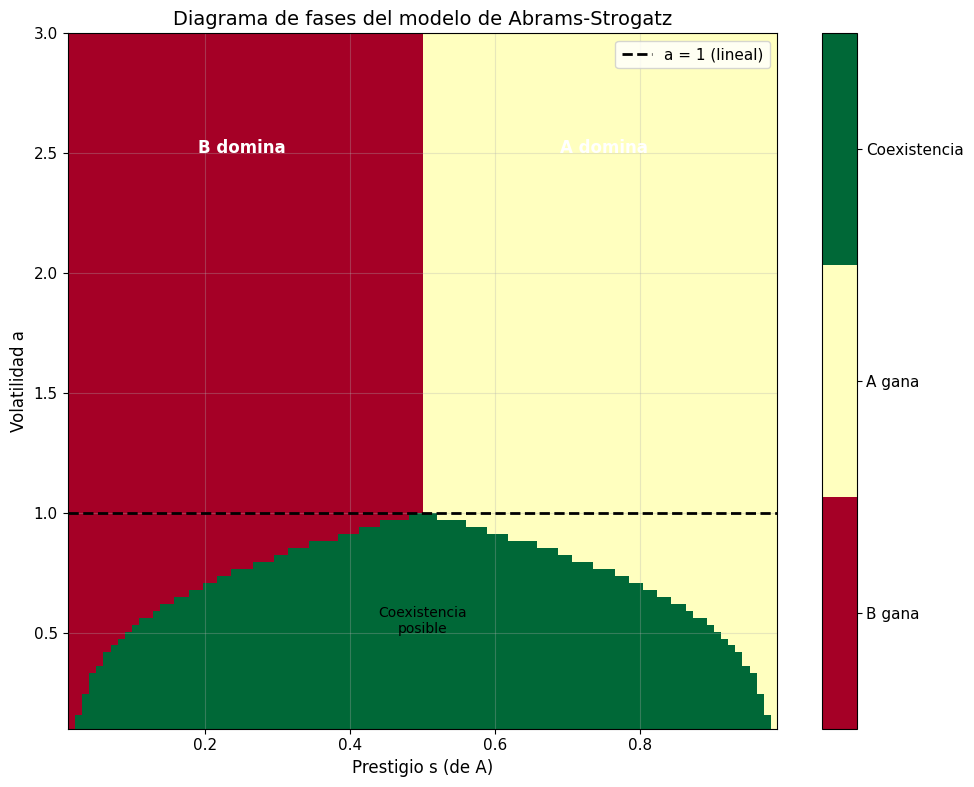


Figura 6: Diagrama de fases del modelo de Abrams-Strogatz.
Parámetros: s = prestigio del lenguaje A, a = volatilidad.
Para a > 1 (baja volatilidad): Uno de los lenguajes siempre se extingue.
Para a < 1 (alta volatilidad): Posible coexistencia en s = 0.5.


In [ ]:
# ============================================
# Diagrama de fases (s, a)
# ============================================

s_range = np.linspace(0.01, 0.99, 100)
a_range = np.linspace(0.1, 3.0, 100)

# Classify each point según el número de puntos fijos estables
phase_diagram = np.zeros((len(a_range), len(s_range)))

for i, a in enumerate(a_range):
    for j, s in enumerate(s_range):
        fps = find_fixed_points(s, a)
        
        # Contar puntos fijos estables (excluyendo 0 y 1)
        stable_interior = 0
        for fp in fps:
            if 0.01 < fp < 0.99 and check_stability(fp, s, a):
                stable_interior += 1
        
        # Clasificar
        if stable_interior > 0:
            phase_diagram[i, j] = 2  # Coexistencia
        elif s > 0.5:
            phase_diagram[i, j] = 1  # A gana
        else:
            phase_diagram[i, j] = 0  # B gana

fig, ax = plt.subplots(figsize=(10, 8))

# Plot
cmap = plt.cm.get_cmap('RdYlGn', 3)
im = ax.imshow(phase_diagram, extent=[s_range[0], s_range[-1], a_range[0], a_range[-1]],
               origin='lower', aspect='auto', cmap=cmap, vmin=-0.5, vmax=2.5)

# Critical line a = 1
ax.axhline(1, color='black', linestyle='--', lw=2, label='a = 1 (lineal)')

ax.set_xlabel('Prestigio s (de A)', fontsize=12)
ax.set_ylabel('Volatilidad a', fontsize=12)
ax.set_title('Diagrama de fases del modelo de Abrams-Strogatz', fontsize=14)

# Colorbar
cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2])
cbar.ax.set_yticklabels(['B gana', 'A gana', 'Coexistencia'])

# Annotations
ax.text(0.25, 2.5, 'B domina', fontsize=12, ha='center', color='white', fontweight='bold')
ax.text(0.75, 2.5, 'A domina', fontsize=12, ha='center', color='white', fontweight='bold')
ax.text(0.5, 0.5, 'Coexistencia\nposible', fontsize=10, ha='center', color='black')

ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

print("\nFigura 6: Diagrama de fases del modelo de Abrams-Strogatz.")
print("Parámetros: s = prestigio del lenguaje A, a = volatilidad.")
print("Para a > 1 (baja volatilidad): Uno de los lenguajes siempre se extingue.")
print("Para a < 1 (alta volatilidad): Posible coexistencia en s = 0.5.")

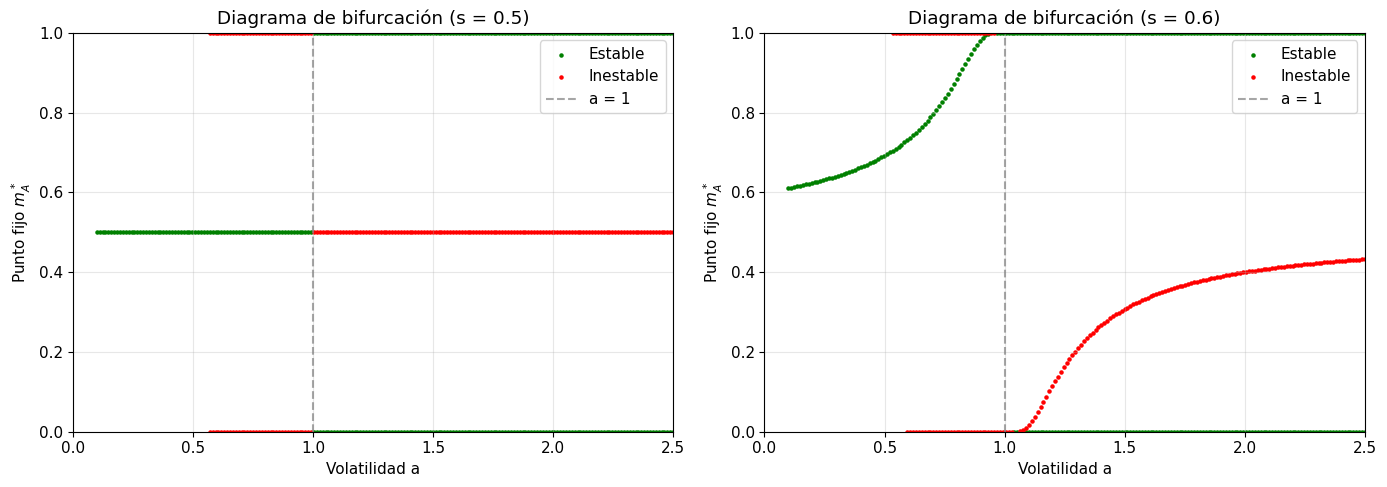


Figura 7: Diagramas de bifurcación del modelo de Abrams-Strogatz.
Izquierda: s = 0.5 (prestigio igual). Bifurcación pitchfork en a = 1.
Derecha: s = 0.6 (A más prestigioso). El lenguaje A siempre domina para a > 1.


In [ ]:
# ============================================
# Análisis de estabilidad: Bifurcación en a
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Diagrama de bifurcación para s = 0.5
s = 0.5
a_range = np.linspace(0.1, 2.5, 200)

stable_fps = []
unstable_fps = []

for a in a_range:
    fps = find_fixed_points(s, a)
    for fp in fps:
        if check_stability(fp, s, a):
            stable_fps.append((a, fp))
        else:
            unstable_fps.append((a, fp))

stable_fps = np.array(stable_fps)
unstable_fps = np.array(unstable_fps)

if len(stable_fps) > 0:
    axes[0].scatter(stable_fps[:, 0], stable_fps[:, 1], c='green', s=5, label='Estable')
if len(unstable_fps) > 0:
    axes[0].scatter(unstable_fps[:, 0], unstable_fps[:, 1], c='red', s=5, label='Inestable')

axes[0].axvline(1, color='gray', linestyle='--', alpha=0.7, label='a = 1')
axes[0].set_xlabel('Volatilidad a')
axes[0].set_ylabel(r'Punto fijo $m_A^*$')
axes[0].set_title(f'Diagrama de bifurcación (s = {s})')
axes[0].legend()
axes[0].set_xlim(0, 2.5)
axes[0].set_ylim(0, 1)

# Panel 2: Diagrama de bifurcación para s = 0.6
s = 0.6

stable_fps = []
unstable_fps = []

for a in a_range:
    fps = find_fixed_points(s, a)
    for fp in fps:
        if check_stability(fp, s, a):
            stable_fps.append((a, fp))
        else:
            unstable_fps.append((a, fp))

stable_fps = np.array(stable_fps)
unstable_fps = np.array(unstable_fps)

if len(stable_fps) > 0:
    axes[1].scatter(stable_fps[:, 0], stable_fps[:, 1], c='green', s=5, label='Estable')
if len(unstable_fps) > 0:
    axes[1].scatter(unstable_fps[:, 0], unstable_fps[:, 1], c='red', s=5, label='Inestable')

axes[1].axvline(1, color='gray', linestyle='--', alpha=0.7, label='a = 1')
axes[1].set_xlabel('Volatilidad a')
axes[1].set_ylabel(r'Punto fijo $m_A^*$')
axes[1].set_title(f'Diagrama de bifurcación (s = {s})')
axes[1].legend()
axes[1].set_xlim(0, 2.5)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nFigura 7: Diagramas de bifurcación del modelo de Abrams-Strogatz.")
print("Izquierda: s = 0.5 (prestigio igual). Bifurcación pitchfork en a = 1.")
print("Derecha: s = 0.6 (A más prestigioso). El lenguaje A siempre domina para a > 1.")

### Discussion — Exercise 2

**Fixed points of the Abrams-Strogatz model:**

1. **Trivial fixed points**: $m_A^* = 0$ (extinction of A) and $m_A^* = 1$ (extinction of B).

2. **Coexistence fixed point**: $m_A^* = 0.5$ (when $s = 0.5$, exists only for $a < 1$).

**Stability analysis:**

| Condition | Stable fixed points | Interpretation |
|-----------|---------------------|----------------|
| $s=0.5$, $a<1$ | $m_A^* = 0.5$ | Stable coexistence |
| $s=0.5$, $a>1$ | $m_A^* = 0$ or $m_A^* = 1$ | One language wins (depends on IC) |
| $s>0.5$, $a>1$ | $m_A^* = 1$ | A always dominates |
| $s<0.5$, $a>1$ | $m_A^* = 0$ | B always dominates |

**Critical line $a = 1$**: on this line all states $m_A \in [0,1]$ are marginally stable — the dynamics are neutral.

**Empirical fit**: for many historically documented language pairs, best fits give $a \approx 1.3$, placing them in the winner-takes-all regime — consistent with the global trend towards language extinction.
